# CD16-Mono trajectory validation

Loads the Loop 5 residual AnnData, compares CD41a and classifies cells, then plots CD16-Mono cell-type proportions against existing protocols.

In [1]:
import numpy as np
import scanpy as sc
sc.settings.figdir = "../plots"
import pandas as pd
import seaborn as sns
import logging
import os
import sys
import traceback
import yaml
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
from hydra import initialize, compose
from omegaconf import DictConfig
from tqdm import tqdm
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import confusion_matrix, classification_report
from torch.utils.data import DataLoader, TensorDataset

sys.path.insert(0, "../../../shared_utils")
from experiment_utils import get_forward_model

In [2]:
# adata = sc.read_h5ad("../../../project_folder/output/loops/data/loop5/adata_500k_residual.h5ad")
adata = sc.read_h5ad("../../../project_folder/output/loops/data/loop5/adata_full_residual.h5ad")

In [3]:
cd16_layer = list(adata.var.index).index('CD16')
positive_mask = adata.layers["positives"][:, 1]

In [4]:
experiments = [
    "267",
    "268",
    "277", 
]

adata_cd16mono = adata[adata.obs.experiment_number.isin(experiments)]

In [5]:
pd.crosstab(adata_cd16mono.obs.replicate, 
            adata_cd16mono.obs.experiment_number)

experiment_number,267,268,277
replicate,,,
1,182839,107680,122339
2,194853,134604,74052
3,162844,36153,51248
4,158148,65497,60708
5,112982,139867,48341


## Check comparison CD41a 

In [6]:
cd16_df = {"CD16": adata_cd16mono[:,"CD16"].X.toarray().ravel(), 
             "experiment_number": adata_cd16mono.obs["experiment_number"].values}

In [7]:
cd16_df = pd.DataFrame(cd16_df)

<Axes: xlabel='experiment_number', ylabel='CD16'>

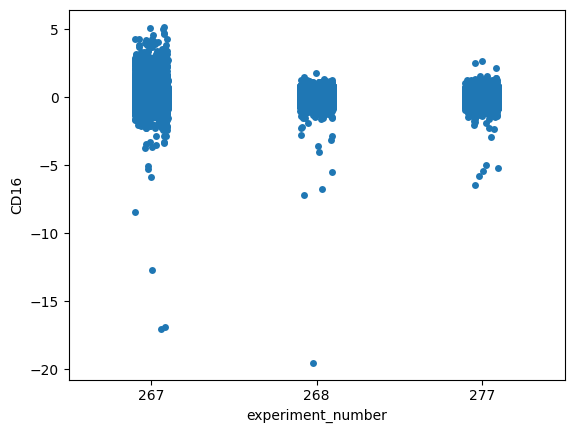

In [8]:
sns.stripplot(cd16_df, x="experiment_number", y="CD16")

# Classification 

In [9]:
os.environ["REPO_ROOT"] = os.path.abspath("../../..")

with initialize(config_path="../../../inverse/loss_guidance/config", version_base=None):
    config = compose(config_name="run_inverse",
                    overrides=[
                        "paths=bloodplus_fm"
                    ])

ANNOTATION_CFG_FILE = "../../../inverse/loss_guidance/config/annotation/default.yaml"
with open(ANNOTATION_CFG_FILE, "r") as fb:
    annotation_cfg = yaml.safe_load(fb)
protocol_cols = annotation_cfg["protocol_columns"]

logger = logging.getLogger(__name__)

forward_model, (
    flow_matching,
    target_prediction_model
) = get_forward_model(config, logger=logger)

In [10]:
# Standardization parameters 
train_adata_g = target_prediction_model.train_data.adata
scatter_params = train_adata_g.uns["X_scatter_params"]
channel_params = train_adata_g.uns["X_channel_params"]
scatter_params.keys(), channel_params.keys()

adata_cd16mono.obs.columns = [
    col.split(' :: ')[-1] if ' :: ' in col else col
    for col in adata_cd16mono.obs.columns
]

In [11]:
X_channel = adata_cd16mono.X
X_channel = (X_channel - channel_params["mean"])/channel_params["std"]
X_scatter = []

for col in config.annotation.scatter_columns:
    col_vals = adata_cd16mono.obs[col].astype(float).values
    X_scatter.append(col_vals)
    
X_scatter = np.stack(X_scatter, axis=1)
X_scatter = (X_scatter - scatter_params["mean"])/scatter_params["std"]

X = np.concatenate(
    (
        X_channel, X_scatter
    ), axis=1
)

print(f"{X_channel.shape=} {X_scatter.shape=}")

X_channel.shape=(1652155, 20) X_scatter.shape=(1652155, 6)


In [12]:
dataloader = DataLoader(
    torch.utils.data.TensorDataset(torch.from_numpy(X)), 
    batch_size=4026,
    shuffle=False
)

ct_predictions = []

with torch.no_grad():
    for batch in tqdm(dataloader):
        X_batch = batch[0].to(target_prediction_model.device).to(torch.float32)
        y_pred = target_prediction_model.predict(X_batch)["cell_type"].argmax(1)
        ct_predictions.append(y_pred.cpu().detach().numpy())
ct_predictions = np.concatenate(ct_predictions)

100%|██████████| 411/411 [00:06<00:00, 60.52it/s] 


In [13]:
# Prepare label encoder
ct_le = LabelEncoder()
ct_values = train_adata_g.obs["cell_type"].values
ct_le.fit(ct_values)
classes = np.array(ct_le.classes_.tolist())

In [14]:
ct_predictions_str = classes[ct_predictions]
adata_cd16mono.obs["cell_type"] = ct_predictions_str

/tmp/ipykernel_3594316/2223418764.py:2: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  adata_cd16mono.obs["cell_type"] = ct_predictions_str


In [15]:
# with plt.rc_context({"figure.figsize": (3, 2), "figure.dpi": 150}):
#     sc.pl.umap(
#         adata_cd16mono,
#         color="cell_type",
#         s=50,
#         groups="CD16Mono",
#         palette=["firebrick"],
#         frameon=False,
#         save="_cd16mono_umap.png",
#     )

## Plot cell type props

In [16]:
unique_ct = np.unique(adata_cd16mono.obs["cell_type"])

In [17]:
props_per_exp = {"Exp": [], 
                "mean_cd16": [],
                "replicates": [], 
                "prop_cd16mono": [], 
                "prop_cd16mono_lin": [],
                "count_cd16mono": [],
                "count_cd16mono_lin": [],
                "log_count_cd16mono": [],
                "log_count_cd16mono_lin": []}

for exp in experiments:
    adata_cd16mono_exp = adata_cd16mono[adata_cd16mono.obs["experiment_number"] == exp]
    replicates = adata_cd16mono_exp.obs["replicate"].unique()
    
    for rep in replicates:
        adata_cd16mono_rep = adata_cd16mono_exp[adata_cd16mono_exp.obs["replicate"] == rep]        
        
        counts = adata_cd16mono_rep.obs.cell_type.value_counts()
        for ct in classes:
            if ct not in counts.index:
                counts[ct] = 0
        props = counts / counts.sum()
        
        count_cd16mono = counts["CD16Mono"]
        count_cd16mono_lin = counts["CD16Mono"] + counts["CD14Mono"]
        
        props_per_exp["Exp"].append(exp)
        props_per_exp["replicates"].append(rep)
        props_per_exp["prop_cd16mono"].append(props["CD16Mono"])
        props_per_exp["prop_cd16mono_lin"].append(props["CD16Mono"] + props["CD14Mono"])
        props_per_exp["count_cd16mono"].append(count_cd16mono)
        props_per_exp["count_cd16mono_lin"].append(count_cd16mono_lin)
        props_per_exp["log_count_cd16mono"].append(np.log1p(count_cd16mono))
        props_per_exp["log_count_cd16mono_lin"].append(np.log1p(count_cd16mono_lin))
        
        cd16_vals = adata_cd16mono_rep[:, "CD16"].X.toarray().ravel()
        positives = adata_cd16mono_rep.layers["positives"][:, cd16_layer].astype(bool)
        cd16_vals = cd16_vals[positives]
        
        if cd16_vals.size == 0:
            props_per_exp["mean_cd16"].append(np.nan)
        else:
            top25_thresh = np.quantile(cd16_vals, 0.75)
            props_per_exp["mean_cd16"].append(cd16_vals[cd16_vals >= top25_thresh].mean())

props_per_exp_df = pd.DataFrame(props_per_exp)
props_per_exp_df

,Exp,mean_cd16,replicates,prop_cd16mono,prop_cd16mono_lin,count_cd16mono,count_cd16mono_lin,log_count_cd16mono,log_count_cd16mono_lin
0,267,1.941228,1,0.073907,0.074065,13513,13542,9.511481,9.513625
1,267,2.045706,2,0.075832,0.076027,14776,14814,9.600827,9.603395
2,267,2.327185,3,0.078891,0.079149,12847,12889,9.460943,9.464207
3,267,2.608949,4,0.089897,0.089954,14217,14226,9.562264,9.562897
4,267,2.743509,5,0.083863,0.083943,9475,9484,9.156518,9.157467
5,268,1.031926,1,0.089590,0.089664,9647,9655,9.174506,9.175335
6,268,1.032886,2,0.094967,0.095027,12783,12791,9.455950,9.456575
7,268,0.918010,3,0.092966,0.093021,3361,3363,8.120291,8.120886
8,268,0.954985,4,0.097989,0.098050,6418,6422,8.767018,8.767641
9,268,1.105064,5,0.078146,0.078174,10930,10934,9.299358,9.299724


In [18]:
props_per_exp_df["Exp"] = props_per_exp_df["Exp"].apply(
    lambda x: "277 (positive control)" if x == "277" else x
)
props_per_exp_df

,Exp,mean_cd16,replicates,prop_cd16mono,prop_cd16mono_lin,count_cd16mono,count_cd16mono_lin,log_count_cd16mono,log_count_cd16mono_lin
0,267,1.941228,1,0.073907,0.074065,13513,13542,9.511481,9.513625
1,267,2.045706,2,0.075832,0.076027,14776,14814,9.600827,9.603395
2,267,2.327185,3,0.078891,0.079149,12847,12889,9.460943,9.464207
3,267,2.608949,4,0.089897,0.089954,14217,14226,9.562264,9.562897
4,267,2.743509,5,0.083863,0.083943,9475,9484,9.156518,9.157467
5,268,1.031926,1,0.089590,0.089664,9647,9655,9.174506,9.175335
6,268,1.032886,2,0.094967,0.095027,12783,12791,9.455950,9.456575
7,268,0.918010,3,0.092966,0.093021,3361,3363,8.120291,8.120886
8,268,0.954985,4,0.097989,0.098050,6418,6422,8.767018,8.767641
9,268,1.105064,5,0.078146,0.078174,10930,10934,9.299358,9.299724


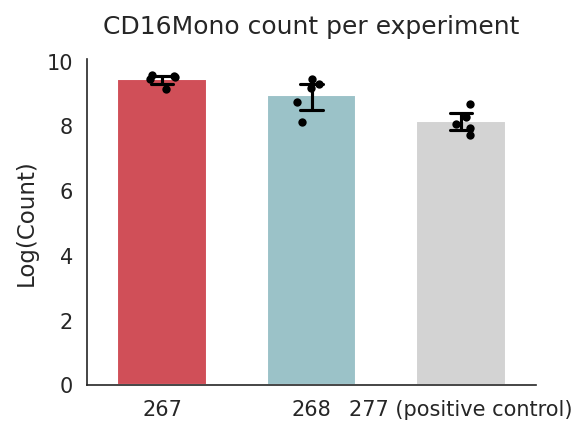

In [20]:
sns.set_style("white")
color_map = {
    "267": "#E63946",
    "268": "#94C7CF",
    "277 (positive control)": "lightgray"
}
fig, ax = plt.subplots(figsize=(4, 3), dpi=150)
sns.barplot(
    props_per_exp_df,
    x="Exp",
    y="log_count_cd16mono",
    hue="Exp",
    palette=color_map,
    legend=False,
    width=0.6,
    errorbar=("ci", 95),
    n_boot=1000,
    seed=0,
    capsize=0.15,
    err_kws={"color": "black", "linewidth": 1.5},
    ax=ax
)
sns.stripplot(
    props_per_exp_df,
    x="Exp",
    y="log_count_cd16mono",
    color="black",
    size=4,
    jitter=True,
    ax=ax
)
ax.set_xlabel("")
ax.set_ylabel("Log(Count)", fontsize=11)
ax.set_title("CD16Mono count per experiment", fontsize=12, pad=12)
sns.despine(ax=ax)
ax.tick_params(axis="both", labelsize=10)
plt.tight_layout()
plt.show()

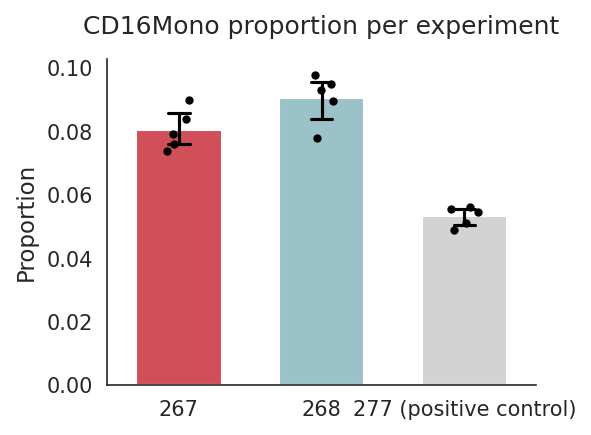

In [21]:
sns.set_style("white")
color_map = {
    "267": "#E63946",
    "268": "#94C7CF",
    "277 (positive control)": "lightgray"
}
fig, ax = plt.subplots(figsize=(4, 3), dpi=150)
sns.barplot(
    props_per_exp_df,
    x="Exp",
    y="prop_cd16mono_lin",
    hue="Exp",
    palette=color_map,
    legend=False,
    width=0.6,
    errorbar=("ci", 95),
    n_boot=1000,
    seed=0,
    capsize=0.15,
    err_kws={"color": "black", "linewidth": 1.5},
    ax=ax
)
sns.stripplot(
    props_per_exp_df,
    x="Exp",
    y="prop_cd16mono_lin",
    color="black",
    size=4,
    jitter=True,
    ax=ax
)
ax.set_xlabel("")
ax.set_ylabel("Proportion", fontsize=11)
ax.set_title("CD16Mono proportion per experiment", fontsize=12, pad=12)
sns.despine(ax=ax)
ax.tick_params(axis="both", labelsize=10)
plt.tight_layout()
fig.savefig("../plots/prop_cd16mon_lin_barplot.png", dpi=300, bbox_inches="tight")
plt.show()

## Compare to existing protocols

In [ ]:
adata_l1 = sc.read_h5ad("../../../project_folder/output/loops/data/loop1/adata_500k.h5ad")
adata_l2 = sc.read_h5ad("../../../project_folder/derived/annotated/loop2_annotated.h5ad")
adata_l2p5 = sc.read_h5ad("../../../project_folder/derived/annotated/loop2p5_annotated.h5ad")
adata_l3 = sc.read_h5ad("../../../project_folder/derived/annotated/loop3_annotated.h5ad")

In [ ]:
adata_concat = sc.concat([adata_l1, adata_l2, adata_l2p5, adata_l3])                       

In [ ]:
adata_concat.obs["experiment_number"] = adata_concat.obs["experiment_number"].astype(str)

In [ ]:
for exp in np.unique(adata_concat.obs.experiment_number):
    adata_cd16mono_exp = adata_concat[adata_concat.obs["experiment_number"]==exp]
    props = adata_cd16mono_exp.obs.cell_type.value_counts()
    props = props / props.sum()
    for ct in classes: 
        if ct not in props.index:
            props[ct] = 0
            
    props_per_exp["Exp"].append(exp)
    props_per_exp["prop_cd16mono"].append(props["CD16Mono"])
    props_per_exp["prop_cd16mono_lin"].append(props["CD16Mono"]+props["CD14Mono"])
    cd16_vals = adata_cd16mono_exp[:, "CD16"].X.toarray().ravel()
    top25_thresh = np.quantile(cd16_vals, 0.75)
    props_per_exp["mean_cd16"].append(cd16_vals[cd16_vals >= top25_thresh].mean())

props_per_exp_df = pd.DataFrame(props_per_exp)
props_per_exp_df

In [ ]:
props_per_exp = pd.DataFrame(props_per_exp)

In [ ]:
sns.set_style("white")
fig, ax = plt.subplots(figsize=(5, 3))
highlight = ["267",
               "268"]
colors = props_per_exp_df["Exp"].apply(
    lambda e: "firebrick" if e in highlight else "lightgray"
)
sns.scatterplot(
    data=props_per_exp_df,
    x="mean_cd16",
    y="prop_cd16mono_lin",
    s=100,
    edgecolor="none",
    color=colors,
    ax=ax,
)
ax.set_xlabel("Mean CD16 (top 25%)", fontsize=12)
ax.set_ylabel("Proportion of monocytes", fontsize=12)
ax.set_title("CD16Mono proportion vs. CD16 expression", fontsize=11, pad=10)
ax.tick_params(axis="both", labelsize=11)
sns.despine(ax=ax)
plt.tight_layout()
plt.savefig("../plots/cd16mono_scatter.png", dpi=300, bbox_inches="tight")
plt.show()